<a href="https://colab.research.google.com/github/nikaduri/ml-facial-expression-recognition/blob/main/model_experiment_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('challenges-in-representation-learning-facial-expression-recognition-challenge')

100%|██████████| 285M/285M [00:17<00:00, 16.7MB/s]

Extracting files...


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tarfile
import zipfile

# Dataset Import

In [4]:
print("--- Searching Downloaded Path ---")
for root, dirs, files in os.walk(path):
    for file in files:
        print(f"Found: {os.path.join(root, file)}")

--- Searching Downloaded Path ---
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv


In [5]:
for root, dirs, files in os.walk(path):
    for file in files:
        file_path = os.path.join(root, file)
        if file.endswith('.tar.gz') or file.endswith('.tgz'):
            print(f"\nExtracting archive: {file}...")
            with tarfile.open(file_path, "r:gz") as tar:
                tar.extractall(path=root)
        elif file.endswith('.zip'):
            print(f"\nExtracting archive: {file}...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(root)


Extracting archive: fer2013.tar.gz...


/tmp/ipykernel_2054/3244132510.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=root)


In [9]:
csv_file = None

# Prioritize finding 'train.csv' or 'icml_face_data.csv' as the main dataset
for root, dirs, files in os.walk(path):
    if 'train.csv' in files:
        csv_file = os.path.join(root, 'train.csv')
        break
    elif 'icml_face_data.csv' in files:
        csv_file = os.path.join(root, 'icml_face_data.csv')
        break

if csv_file is None:
    print("\nError: Could not find a suitable main dataset file (e.g., train.csv or icml_face_data.csv) in the downloaded path.")
else:
    print(f"\n--- Loading Dataset from: {csv_file} ---")
    df = pd.read_csv(csv_file)


--- Loading Dataset from: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv ---


# Dataset Analysis

Dataset Shape (Rows, Columns): (28709, 2)


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


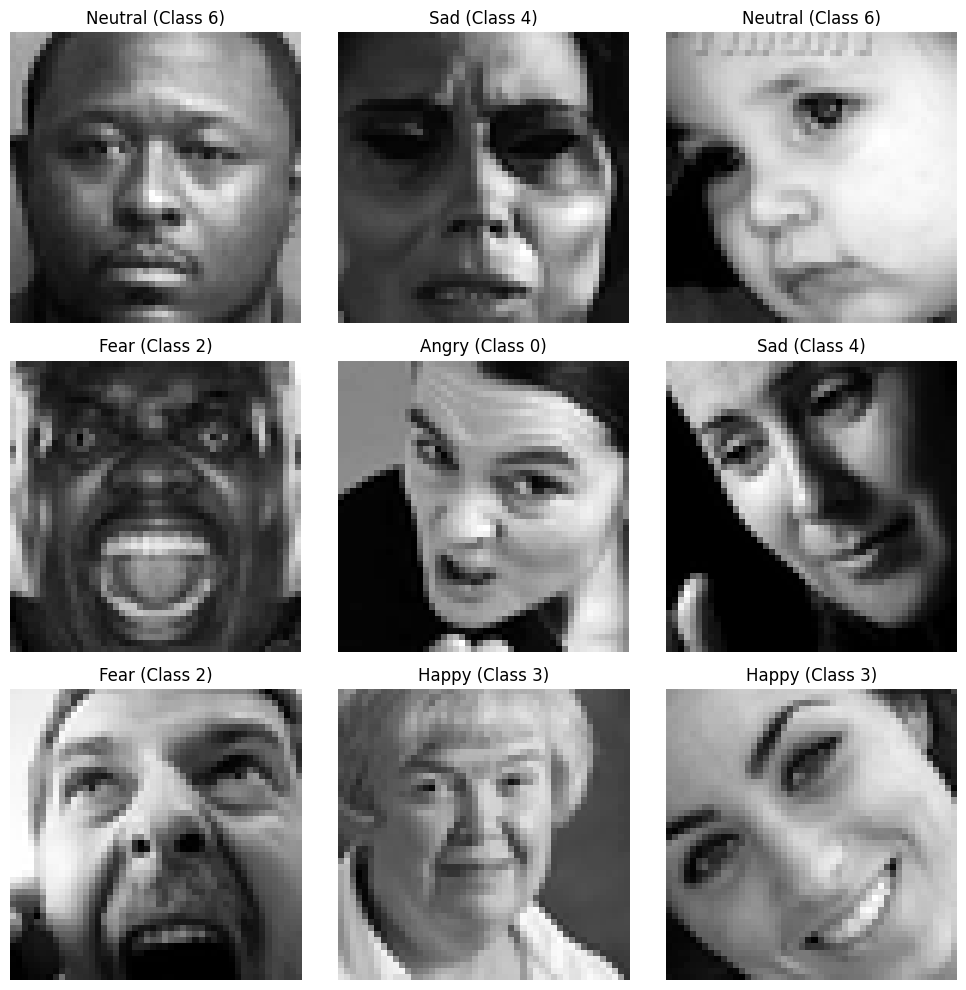

In [10]:
    print(f"Dataset Shape (Rows, Columns): {df.shape}")
    display(df.head())

    emotion_dict = {
        0: 'Angry', 1: 'Disgust', 2: 'Fear',
        3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'
    }

    plt.figure(figsize=(10, 10))

    sample_df = df.sample(9, random_state=42).reset_index(drop=True)

    for i, row in sample_df.iterrows():
        pixels_array = np.array(row['pixels'].split(), dtype='float32')

        image = pixels_array.reshape(48, 48)

        plt.subplot(3, 3, i + 1)
        plt.imshow(image, cmap='gray')

        label_col = 'emotion' if 'emotion' in df.columns else df.columns[0]
        emotion_id = row[label_col]
        emotion_label = emotion_dict.get(emotion_id, "Unknown")

        plt.title(f"{emotion_label} (Class {emotion_id})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [11]:
    if 'emotion' in df.columns:
        distribution = df['emotion'].value_counts().rename(index=emotion_dict)
        print(distribution)

emotion
Happy       7215
Neutral     4965
Sad         4830
Fear        4097
Angry       3995
Surprise    3171
Disgust      436
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['emotion'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Test Samples: {len(test_df)}")

Training Samples: 22967
Validation Samples: 2871
Test Samples: 2871


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixel_string = self.df.iloc[idx]['pixels']

        pixels = np.array(pixel_string.split(), dtype=np.uint8)

        image = pixels.reshape(48, 48)

        image = Image.fromarray(image)

        label_col = 'emotion' if 'emotion' in self.df.columns else self.df.columns[0]
        label = int(self.df.iloc[idx][label_col])

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [15]:
train_dataset = FERDataset(train_df, transform=train_transforms)
val_dataset = FERDataset(val_df, transform=val_test_transforms)
test_dataset = FERDataset(test_df, transform=val_test_transforms)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total Batches in train_loader: {len(train_loader)} (at batch size {batch_size})")
print(f"Total Batches in val_loader: {len(val_loader)}")


images, labels = next(iter(train_loader))
print(f"\nBatch Image Shape: {images.shape}")
print(f"Batch Label Shape: {labels.shape}")

Total Batches in train_loader: 359 (at batch size 64)
Total Batches in val_loader: 45

Batch Image Shape: torch.Size([64, 1, 48, 48])
Batch Label Shape: torch.Size([64])


In [16]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 32 * 12 * 12)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = BaselineCNN()
print(model)

BaselineCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)


In [17]:
import torch
import torch.optim as optim

def test_single_batch_overfit(model, train_loader, device='cpu'):
    print("\n--- Starting Single Batch Overfit Test ---")
    model.to(device)
    model.train()

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    # 1. Grab exactly ONE batch of data
    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)

    print(f"Testing on a single batch of {images.size(0)} images.")

    epochs = 50
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        accuracy = 100 * correct / labels.size(0)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Accuracy: {accuracy:.2f}%")

    if loss.item() < 0.1 and accuracy == 100.0:
        print("\nSUCCESS: The model successfully overfitted the batch")
    else:
        print("\nFAILURE: The model failed to overfit")

test_single_batch_overfit(BaselineCNN(), train_loader, device='cpu')


--- Starting Single Batch Overfit Test ---
Testing on a single batch of 64 images.
Epoch [1/50] | Loss: 1.9360 | Accuracy: 21.88%
Epoch [10/50] | Loss: 0.8638 | Accuracy: 71.88%
Epoch [20/50] | Loss: 0.0194 | Accuracy: 100.00%
Epoch [30/50] | Loss: 0.0002 | Accuracy: 100.00%
Epoch [40/50] | Loss: 0.0000 | Accuracy: 100.00%
Epoch [50/50] | Loss: 0.0000 | Accuracy: 100.00%

SUCCESS: The model successfully overfitted the batch


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 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


wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nikadurishvili3 (ndurishvili) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch [1/15] | Train Loss: 1.6517 | Val Loss: 1.5172 | Val Acc: 42.15%
Epoch [2/15] | Train Loss: 1.4848 | Val Loss: 1.4063 | Val Acc: 45.77%
Epoch [3/15] | Train Loss: 1.4077 | Val Loss: 1.3810 | Val Acc: 47.54%
Epoch [4/15] | Train Loss: 1.3540 | Val Loss: 1.3235 | Val Acc: 48.87%
Epoch [5/15] | Train Loss: 1.3132 | Val Loss: 1.2963 | Val Acc: 49.43%
Epoch [6/15] | Train Loss: 1.2787 | Val Loss: 1.2820 | Val Acc: 51.58%
Epoch [7/15] | Train Loss: 1.2535 | Val Loss: 1.2512 | Val Acc: 52.21%
Epoch [8/15] | Train Loss: 1.2199 | Val Loss: 1.2410 | Val Acc: 53.50%
Epoch [9/15] | Train Loss: 1.1975 | Val Loss: 1.2502 | Val Acc: 52.66%
Epoch [10/15] | Train Loss: 1.1745 | Val Loss: 1.2602 | Val Acc: 52.07%
Epoch [11/15] | Train Loss: 1.1501 | Val Loss: 1.2343 | Val Acc: 53.81%
Epoch [12/15] | Train Loss: 1.1283 | Val Loss: 1.2336 | Val Acc: 53.47%
Epoch [13/15] | Train Loss: 1.1165 | Val Loss: 1.2197 | Val Acc: 54.27%
Epoch [14/15] | Train Loss: 1.0939 | Val Loss: 1.2108 | Val Acc: 55.14%
E

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇██
train_loss,█▆▅▄▄▄▃▃▃▂▂▂▂▁▁
val_accuracy,▁▃▄▅▅▆▆▇▇▆▇▇███
val_loss,█▅▅▄▃▃▂▂▂▂▂▂▁▁▁
epoch,15
train_accuracy,59.49841
train_loss,1.07012
val_accuracy,54.61512
val_loss,1.20961


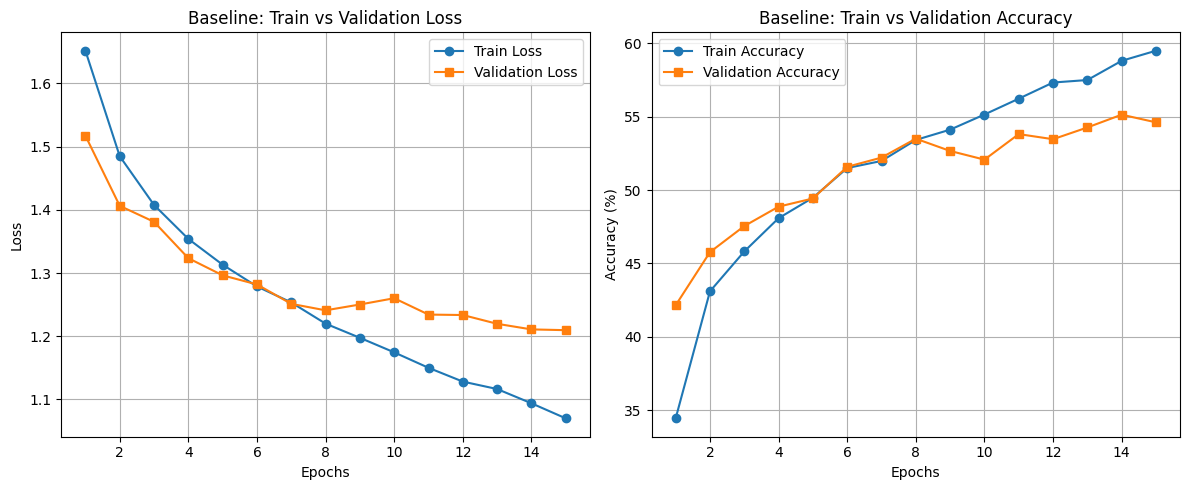

Saved plot to baseline_curves.png for your README.


In [18]:
import wandb
import torch.optim as optim
import matplotlib.pyplot as plt

def train_baseline_model(model, train_loader, val_loader, epochs=15, device='cpu'):
    wandb.init(
        project="facial-expression-recognition",
        name="Architecture_A_Baseline",
        config={
            "learning_rate": 0.001,
            "architecture": "2-Layer CNN",
            "epochs": epochs,
            "batch_size": 64
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate)

    wandb.watch(model, criterion, log="all", log_freq=10)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    model.to(device)

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })

        # Save history for local plotting
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    wandb.finish()
    return history

def plot_learning_curves(history, save_path="baseline_curves.png"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='s')
    plt.title('Baseline: Train vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s')
    plt.title('Baseline: Train vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved plot to {save_path} for your README.")

history = train_baseline_model(model, train_loader, val_loader, epochs=15, device='cuda')
plot_learning_curves(history)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN_Optimized(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN_Optimized, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.fc1 = nn.Linear(32 * 12 * 12, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 32 * 12 * 12)

        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract the training labels
y_train = train_df['emotion'].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class Weights:", weights_tensor.cpu().numpy())

Class Weights: [1.0265957 9.401146  1.0012206 0.5684338 0.8491201 1.2932597 0.8260322]


In [23]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_accuracy',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [1e-3, 5e-4, 1e-4]
        },
        'optimizer': {
            'values': ['adam', 'sgd']
        },
        'dropout_rate': {
            'values': [0.3, 0.5, 0.7]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")

Create sweep with ID: 9tznb02u
Sweep URL: https://wandb.ai/ndurishvili/facial-expression-recognition/sweeps/9tznb02u


In [24]:
import torch.optim as optim

def sweep_train():
    wandb.init()
    config = wandb.config

    model = BaselineCNN_Optimized().to(device)
    model.dropout.p = config.dropout_rate

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    if config.optimizer == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

    wandb.watch(model, criterion, log="all", log_freq=10)

    epochs = 15
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })


wandb.agent(sweep_id, sweep_train, count=5)

wandb: Agent Starting Run: iajqbj92 with config:
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.001
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▅▅▆▆▆▇▇▇▇████
train_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▁▁
val_accuracy,▁▄▅▅▆▇▆▆▆▇▇▇▇██
val_loss,█▆▅▄▃▃▂▂▂▂▂▁▁▁▁
epoch,15
train_accuracy,46.82806
train_loss,1.34694
val_accuracy,50.05225
val_loss,1.30717


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: i6iic01j with config:
wandb: 	dropout_rate: 0.7
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▄▅▆▆▆▇▇▇█▇███
train_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁
val_accuracy,▁▁▁▃▃▅▅▆▆▆▇▇█▇█
val_loss,█▇▆▅▄▄▃▃▃▂▂▂▁▁▁
epoch,15
train_accuracy,41.32451
train_loss,1.49887
val_accuracy,47.47475
val_loss,1.37796


wandb: Agent Starting Run: t81v4e0f with config:
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: adam
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▄▅▆▆▇▇▇▇▇████
train_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁
val_accuracy,▁▃▄▆▆▆▇▇▇▇█████
val_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁
epoch,15
train_accuracy,47.70758
train_loss,1.34242
val_accuracy,50.29606
val_loss,1.2874


wandb: Agent Starting Run: iqgg3nef with config:
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▅▅▆▆▇▇▇▇▇████
train_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁
val_accuracy,▁▃▃▅▆▆▆▇▆▇▇██▇█
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▁▁▁
epoch,15
train_accuracy,45.487
train_loss,1.39064
val_accuracy,49.70394
val_loss,1.31029


wandb: Agent Starting Run: 51bdh1wk with config:
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: adam
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▅▆▆▆▇▇▇▇▇████
train_loss,█▆▅▄▄▃▃▂▂▂▂▂▂▁▁
val_accuracy,▁▃▄▅▆▆▆▆▇▇▇████
val_loss,█▆▅▄▃▃▂▂▂▁▁▁▁▁▁
epoch,15
train_accuracy,50.455
train_loss,1.24155
val_accuracy,52.97806
val_loss,1.23079


--- Generating Predictions for Confusion Matrix ---


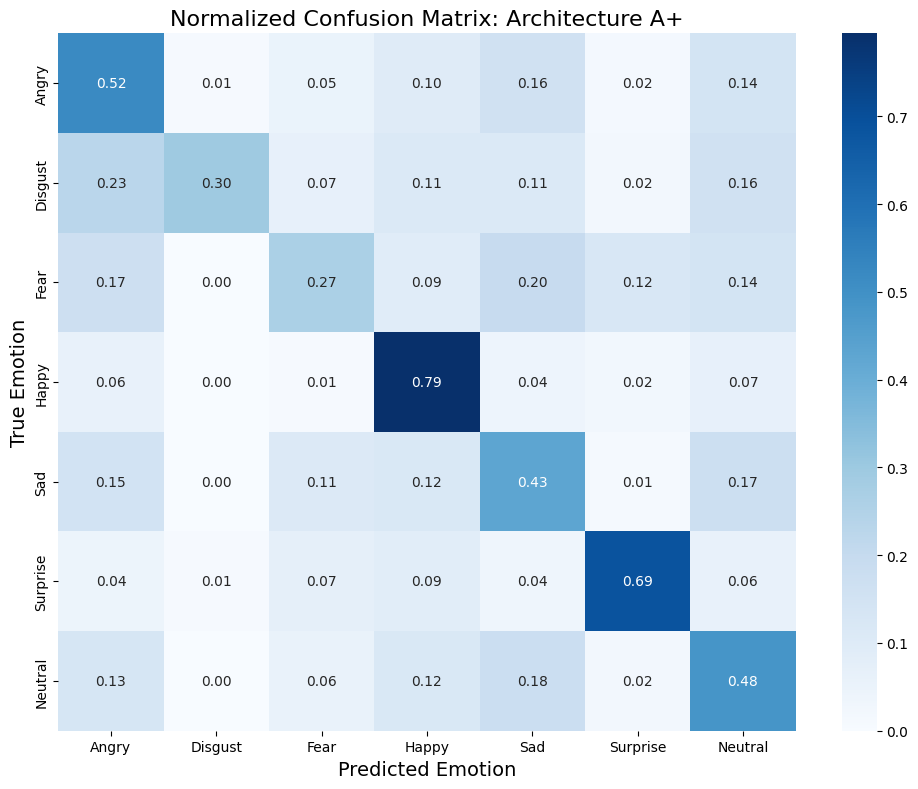

Saved confusion matrix to confusion_matrix.png


In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model_with_hooks, val_loader, device='cuda', save_path="confusion_matrix.png"):
    clean_model = type(model_with_hooks)() # Instantiate a new model of the same class
    clean_model.load_state_dict(model_with_hooks.state_dict()) # Load the trained weights

    clean_model.eval()
    clean_model.to(device)

    all_preds = []
    all_labels = []

    print("--- Generating Predictions for Confusion Matrix ---")
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = clean_model(inputs) # Use the clean model here
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Standard FER2013 labels
    emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

    # Calculate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalize the confusion matrix (shows percentages instead of raw counts)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_labels, yticklabels=emotion_labels)

    plt.title('Normalized Confusion Matrix: Architecture A+', fontsize=16)
    plt.ylabel('True Emotion', fontsize=14)
    plt.xlabel('Predicted Emotion', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix to {save_path}")

plot_confusion_matrix(model, val_loader, device='cuda')

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArchitectureB(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(ArchitectureB, self).__init__()

        # --- Block 1 ---
        self.conv1a = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Block 2 ---
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Block 3 ---
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Classifier ---
        # 48x48 image pooled 3 times (factor of 8) -> 6x6 spatial dimensions
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.pool1(F.relu(self.bn1b(self.conv1b(F.relu(self.bn1a(self.conv1a(x)))))))

        # Block 2
        x = self.pool2(F.relu(self.bn2b(self.conv2b(F.relu(self.bn2a(self.conv2a(x)))))))

        # Block 3
        x = self.pool3(F.relu(self.bn3b(self.conv3b(F.relu(self.bn3a(self.conv3a(x)))))))

        # Flatten
        x = x.view(-1, 128 * 6 * 6)

        # Classifier
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = ArchitectureB()
print(model)

ArchitectureB(
  (conv1a): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True

In [28]:
import wandb
import torch.optim as optim

sweep_config_b = {
    'method': 'bayes',
    'metric': {'name': 'val_accuracy', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [1e-3, 5e-4, 1e-4]},
        'optimizer': {'values': ['adam', 'sgd']},
        'dropout_rate': {'values': [0.4, 0.5, 0.6]},
        'batch_size': {'value': 64} # Kept static for data loader consistency
    }
}

sweep_id_b = wandb.sweep(sweep_config_b, project="facial-expression-recognition")

def sweep_train_b():
    wandb.init()
    config = wandb.config

    model = ArchitectureB(dropout_rate=config.dropout_rate).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    if config.optimizer == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9, weight_decay=1e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)

    wandb.watch(model, criterion, log="all", log_freq=10)

    epochs = 20

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validation
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })

wandb.agent(sweep_id_b, sweep_train_b, count=5)

Create sweep with ID: tk4fzvzm
Sweep URL: https://wandb.ai/ndurishvili/facial-expression-recognition/sweeps/tk4fzvzm


wandb: Agent Starting Run: qmobrriw with config:
wandb: 	batch_size: 64
wandb: 	dropout_rate: 0.6
wandb: 	learning_rate: 0.001
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇██████
val_loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▂▁▁▂
epoch,20
train_accuracy,60.19071
train_loss,0.98187
val_accuracy,59.35214
val_loss,1.13115


wandb: Agent Starting Run: feiddugh with config:
wandb: 	batch_size: 64
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_accuracy,▁▃▃▄▅▅▅▆▆▆▇▇▇▇▇█████
val_loss,█▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁
epoch,20
train_accuracy,50.2939
train_loss,1.27841
val_accuracy,51.54998
val_loss,1.2632


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_accuracy,▁▂▄▅▅▆▆▆▆▇▇▇▇▇▇▇████
val_loss,█▆▅▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▂
epoch,20
train_accuracy,59.86851
train_loss,0.99131
val_accuracy,59.07349
val_loss,1.16013


wandb: Agent Starting Run: ies0utb7 with config:
wandb: 	batch_size: 64
wandb: 	dropout_rate: 0.6
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: adam
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
val_accuracy,▁▃▅▅▅▆▆▇▇▇▇▇▇▇▇█████
val_loss,█▆▄▄▃▃▃▂▂▂▂▁▁▂▁▁▁▂▁▂
epoch,20
train_accuracy,65.09339
train_loss,0.86224
val_accuracy,62.48694
val_loss,1.11188


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ynse9p05 with config:
wandb: 	batch_size: 64
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: adam
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_accuracy,▁▃▄▅▆▅▅▇▇▆▇▇▇▇▇▇████
val_loss,█▆▅▄▃▃▃▂▂▂▁▂▂▂▁▂▂▂▂▃
epoch,20
train_accuracy,66.1645
train_loss,0.83827
val_accuracy,62.45211
val_loss,1.14902


--- Initializing Final Architecture B Run ---
Parameters: LR=0.001, Optimizer=SGD, Dropout=0.6
Epoch [1/20] | Train Acc: 26.96% | Val Acc: 36.05% | Val Loss: 1.5989
Epoch [2/20] | Train Acc: 38.14% | Val Acc: 42.88% | Val Loss: 1.4500
Epoch [3/20] | Train Acc: 43.04% | Val Acc: 46.43% | Val Loss: 1.3617
Epoch [4/20] | Train Acc: 45.38% | Val Acc: 47.61% | Val Loss: 1.3313
Epoch [5/20] | Train Acc: 48.16% | Val Acc: 51.31% | Val Loss: 1.2829
Epoch [6/20] | Train Acc: 49.08% | Val Acc: 52.04% | Val Loss: 1.2244
Epoch [7/20] | Train Acc: 50.67% | Val Acc: 53.22% | Val Loss: 1.2261
Epoch [8/20] | Train Acc: 51.77% | Val Acc: 53.92% | Val Loss: 1.1792
Epoch [9/20] | Train Acc: 53.17% | Val Acc: 54.89% | Val Loss: 1.1852
Epoch [10/20] | Train Acc: 53.84% | Val Acc: 55.59% | Val Loss: 1.1794
Epoch [11/20] | Train Acc: 54.35% | Val Acc: 56.04% | Val Loss: 1.1557
Epoch [12/20] | Train Acc: 56.04% | Val Acc: 56.04% | Val Loss: 1.1414
Epoch [13/20] | Train Acc: 56.74% | Val Acc: 56.98% | Val Loss

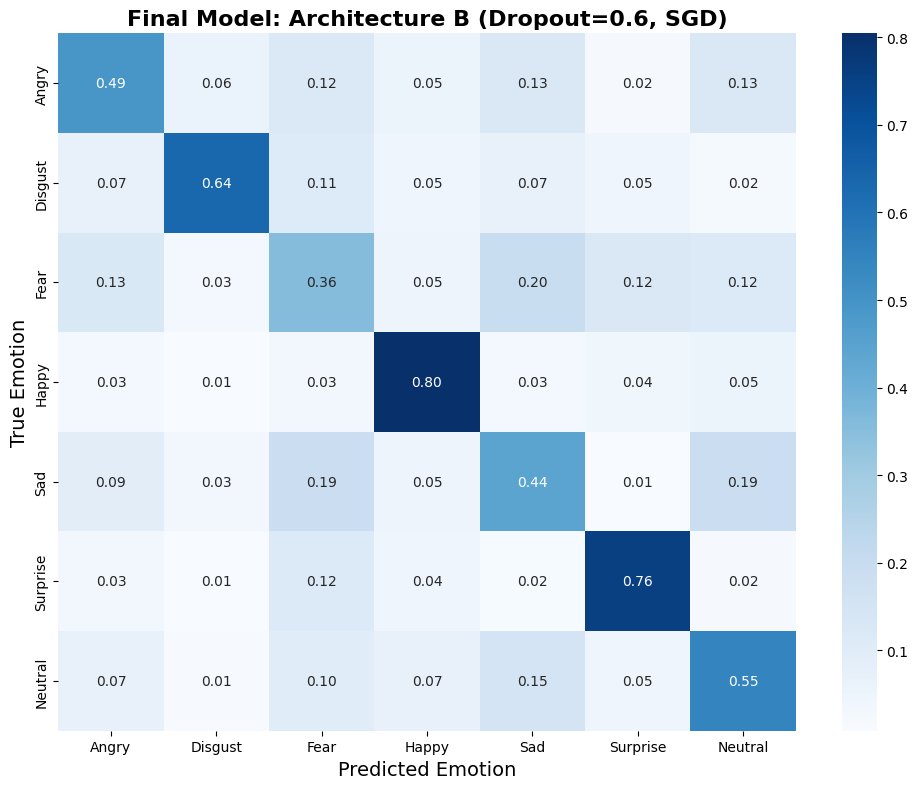

✅ Saved graphic as 'final_arch_b_confusion_matrix.png'


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def run_best_model_and_plot(train_loader, val_loader, weights_tensor, device='cuda', epochs=25):
    print("--- Initializing Final Architecture B Run ---")
    print("Parameters: LR=0.001, Optimizer=SGD, Dropout=0.6")

    # 1. Initialize the Model with your optimal Dropout
    model = ArchitectureB(num_classes=7, dropout_rate=0.6).to(device)

    # 2. Enforce the Weighted Loss (Crucial for proving your point!)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    # 3. Setup the optimal SGD Optimizer
    # Adding standard momentum (0.9) since vanilla SGD can be too slow
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

    # --- TRAINING LOOP ---
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # --- VALIDATION LOOP ---
        model.eval()
        val_loss = 0.0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = 100 * correct_val / total_val
        val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")

    # --- GENERATING THE CONFUSION MATRIX ---
    print("\n--- Training Complete. Generating Confusion Matrix ---")
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

    # Calculate and Normalize
    cm = confusion_matrix(all_labels, all_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_labels, yticklabels=emotion_labels)

    plt.title('Final Model: Architecture B (Dropout=0.6, SGD)', fontsize=16, fontweight='bold')
    plt.ylabel('True Emotion', fontsize=14)
    plt.xlabel('Predicted Emotion', fontsize=14)
    plt.tight_layout()
    plt.savefig('final_arch_b_confusion_matrix.png', dpi=300)
    plt.show()
    print("✅ Saved graphic as 'final_arch_b_confusion_matrix.png'")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_best_model_and_plot(train_loader, val_loader, weights_tensor, device=device, epochs=20)

NameError: name 'epochs' is not defined

<Figure size 800x500 with 0 Axes>